In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import os
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
stem = PorterStemmer().stem
import string
from scipy.sparse import csr_matrix
from unidecode import unidecode

In [13]:
from scipy.sparse import hstack, vstack

In [14]:
for dirname, _, filenames in os.walk('./kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./kaggle/input\comment-category-prediction-challenge\Sample.csv
./kaggle/input\comment-category-prediction-challenge\test.csv
./kaggle/input\comment-category-prediction-challenge\train.csv


### EDA

In [15]:
df = pd.read_csv('./kaggle/input/comment-category-prediction-challenge/train.csv')

In [16]:
df = df.replace('none',np.nan)

In [17]:
df.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            185105
religion        183672
gender          181584
disability           0
comment              1
label                0
dtype: int64

In [18]:
df['gender'].unique(), df['race'].unique(), df['religion'].unique()

(array([nan, 'male', 'female', 'transgender', 'other'], dtype=object),
 array([nan, 'white', 'other', 'asian', 'black', 'latino'], dtype=object),
 array([nan, 'christian', 'muslim', 'jewish', 'atheist', 'other', 'hindu',
        'buddhist'], dtype=object))

#### Null values Analysis
As comment is the most important feature here, the one row without comment can be dropped
As for race, gender, and religion, 'none' to be replaced with nan

In [19]:
df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

In [20]:
df.if_1.sort_values().unique()

array([   0,    4,    5,    6,    7,    8,    9,   10,   11,   12,  249,
        250, 1232, 1254, 1256, 1257, 1258, 1263, 1267, 1271, 1277, 1538,
       1543, 1545, 1547, 1548, 1551, 1553, 1557, 1558, 1560, 1566, 1569,
       1572, 1576, 1581, 1583, 1584, 1585, 1767, 1777, 1778, 1783, 1800,
       1807, 1810, 1811, 1814, 1815, 1819, 1825, 1827, 1830, 1838, 1846,
       1848, 1860])

In [21]:
df['emoticon_1'].unique()

array([ 0,  1, 15,  2,  3,  4,  5, 11,  6,  7,  8, 24, 12, 17, 14, 13,  9,
       10, 20, 16, 25, 18, 21, 19, 23, 36, 22, 28, 27, 33, 30, 46, 32, 47,
       31, 39])

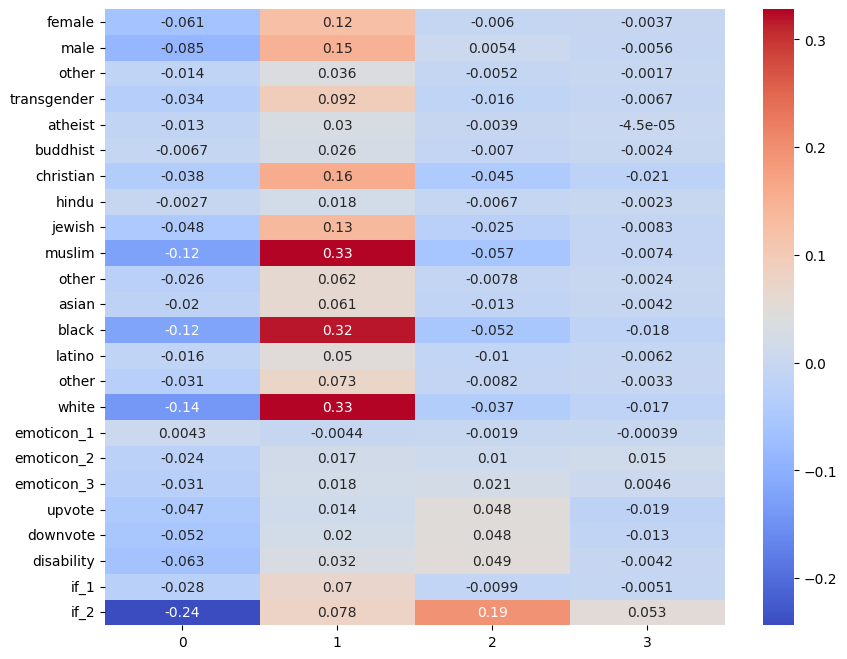

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

hm = pd.concat([
    pd.get_dummies(df['label']).astype(int),
    pd.get_dummies(df['gender']).astype(int),
    pd.get_dummies(df['religion']).astype(int),
    pd.get_dummies(df['race']).astype(int),
    df[['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote','disability','if_1', 'if_2']]], 
          axis=1).corr() \
    .iloc[[0,1,2,3],4:].transpose()

sns.heatmap(hm, annot=True, cmap='coolwarm',)
plt.show()

#### Features to Ignore
1. Created_date: Although time of comment can be argued to be of some use, it's a long shot
2. post_id
3. emoticons: not very clear what the values represent. Intensity of the feature, or index of some value of the feature.
    (While milestones did consider these to be intensity/value, the correlation is not enough to consider these as valid features)

<Axes: ylabel='Frequency'>

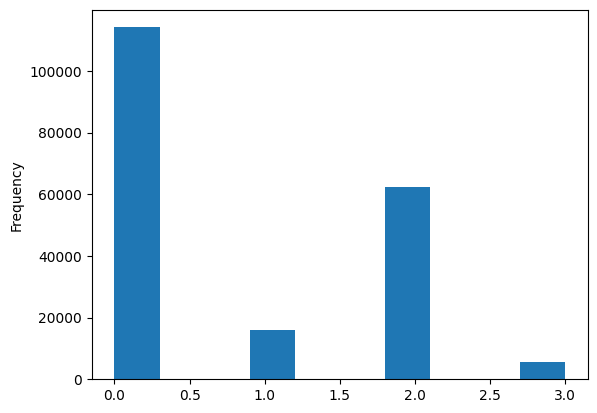

In [23]:
df['label'].plot(kind='hist')

### Data Preprocessing

In [24]:
stop_words = stopwords.words('english')

In [25]:
# Dropping Unnecessary columns, and rows
df = df.drop(['post_id', 'created_date'], axis=1)
df = df.drop(df[df['comment'].isnull()].index).reset_index(drop=True)

In [26]:
# Replacing 'none' with nan
# df[['race', 'religion', 'gender']] = df[['race', 'religion', 'gender']].replace(np.nan,'')

In [27]:
import wordcloud

In [28]:
wc = wordcloud.WordCloud(stopwords=set(stop_words))

plt.imshow(wc.generate(' '.join(df[df['label']==0].comment)))

plt.imshow(wc.generate(' '.join(df[df['label']==1].comment)))

plt.imshow(wc.generate(' '.join(df[df['label']==2].comment)))

plt.imshow(wc.generate(' '.join(df[df['label']==3].comment)))

In [29]:
df.isna().sum()

emoticon_1         0
emoticon_2         0
emoticon_3         0
upvote             0
downvote           0
if_1               0
if_2               0
race          185104
religion      183671
gender        181583
disability         0
comment            0
label              0
dtype: int64

In [30]:
train_df, val_df = train_test_split(df, test_size=.1, stratify=df['label'], random_state=42)

In [31]:
x_train, y_train = train_df[['emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment']], train_df['label']

In [32]:
x_val, y_val = val_df[['emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment']], val_df['label']

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif


In [34]:
from sklearn.decomposition import TruncatedSVD

In [35]:
import re
def clean_text(text):
    text = unidecode(text) # to convert non-ascii chars to ascii
    text = str(text).lower()
    # text = re.sub(r'http\S+', '', text) # removed to keep references
    text = re.sub(r'[^a-zA-Z ]', '',  text) # to replace any non alphabet character with empty string
    text = text.split()
    text = " ".join([i for i in text if len(i)>2 ]) # to remove any word under 2 characters # if len(i)>2 and len(i)<15]  #  if i not in stop_words
    return text


In [36]:
text_pipeline = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='')),
    ('reshape', FunctionTransformer(lambda x: x.ravel())), # convert 2d array to 1d to feed into tfidfvectorizer
    ('tfidf', TfidfVectorizer(preprocessor=clean_text, min_df=2, stop_words='english', norm='l2', sublinear_tf=True)), #, ngram_range=(1,2), max_features=100000
    ])

In [37]:
categorical_cols = ["race", "religion", "gender", "disability"]
df[categorical_cols] = df[categorical_cols].fillna('')
categorical_pipeline = [("imputer", SimpleImputer(strategy="constant", fill_value='none')), # filling with none to use non existence of value as a feature
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ]


numerical_cols = ["upvote", "downvote", "if_1", "if_2","emoticon_1", "emoticon_2", "emoticon_3"] #"emoticon_1", "emoticon_2", "emoticon_3"
numerical_pipeline = [("imputer", SimpleImputer(strategy="constant", fill_value=0)), # filling with mean doesn;t make sense when upvote, and downvote can be 0, and other features are presence of hidden features.
    ("scaler", StandardScaler()) # Standard scaler applied as ranges of each feature is different
    ]

categorical_pipeline = Pipeline(categorical_pipeline)
numerical_pipeline = Pipeline(numerical_pipeline)


preprocessor = ColumnTransformer(
    transformers=[("cat", categorical_pipeline, categorical_cols),
        ("num", numerical_pipeline, numerical_cols),
        ("text", text_pipeline, ['comment'])],
    remainder="passthrough"
)

In [38]:
skb = SelectKBest(k=6000) # 6000 selected based on multiple manual trials on different models
x_train_red = skb.fit_transform(preprocessor.fit_transform(x_train),y_train)
x_val_red = skb.transform(preprocessor.transform(x_val))

### RFC

In [ ]:
# class weight to use in RFC to mitigate bias due to extremely unbalanced class data
from sklearn.utils import class_weight
class_weights = dict(zip(np.unique(y_train),class_weight.compute_class_weight(class_weight='balanced', y=y_train, classes=np.unique(y_train))))

In [119]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
clf = RandomForestClassifier(n_estimators=100, 
                             random_state=42,
                            )
clf.fit(x_train_red, y_train)
y_pred = clf.predict(x_val_red)
# confusion_matrix(y_val, y_pred)
print(accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

In [ ]:
# Trial with test data in training to get a better idea of overfitting/ generalization of model
clf = RandomForestClassifier(n_estimators=100, 
                             random_state=42,
                            #  min_samples_leaf=2, 
                            #  min_samples_split=4,
                            )
clf.fit(vstack([x_train_red,x_val_red]), pd.concat([y_train, y_val]))
y_pred = clf.predict(x_val_red)
# confusion_matrix(y_val, y_pred)
print(accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

In [ ]:
# With class_weights
clf_cw = RandomForestClassifier(n_estimators=100, 
                                random_state=42, 
                                class_weight=class_weights,
                                # min_samples_leaf=2, 
                                # min_samples_split=4
                                )

clf_cw.fit(vstack([x_train_red,x_val_red]), pd.concat([y_train, y_val]))
y_pred = clf_cw.predict(x_val_red)
confusion_matrix(y_val, y_pred)
accuracy_score(y_val, y_pred)
print(classification_report(y_val, y_pred))

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection._search import GridSearchCV

param_grid = {
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'penalty': ['l2', None],
    }
grid_search = GridSearchCV(LogisticRegression(C=2, class_weight='balanced', max_iter=200), param_grid, cv=2, scoring='accuracy', n_jobs=-1, verbose=True)


In [62]:
grid_search.fit(x_train_red, y_train)

Fitting 2 folds for each of 6 candidates, totalling 12 fits
Newton-CG iter = 0
  Check Convergence
    max |gradient| <= tol: 0.09433043765140976 <= 0.0001 False
Newton-CG iter = 1
  Check Convergence
    max |gradient| <= tol: 0.05637255623455533 <= 0.0001 False
Newton-CG iter = 2
  Check Convergence
    max |gradient| <= tol: 0.03233282171219284 <= 0.0001 False
Newton-CG iter = 3
  Check Convergence
    max |gradient| <= tol: 0.03987103147359194 <= 0.0001 False
Newton-CG iter = 4
  Check Convergence
    max |gradient| <= tol: 0.02389491407190245 <= 0.0001 False
Newton-CG iter = 5
  Check Convergence
    max |gradient| <= tol: 0.00660352243337561 <= 0.0001 False
Newton-CG iter = 6
  Check Convergence
    max |gradient| <= tol: 0.0062855973769486255 <= 0.0001 False
Newton-CG iter = 7
  Check Convergence
    max |gradient| <= tol: 0.005208513157110867 <= 0.0001 False
Newton-CG iter = 8
  Check Convergence
    max |gradient| <= tol: 0.03426547419483486 <= 0.0001 False
Newton-CG iter = 9


GridSearchCV(cv=2,
             estimator=LogisticRegression(C=2, class_weight='balanced',
                                          max_iter=200, verbose=True),
             n_jobs=-1,
             param_grid={'penalty': ['l2', None],
                         'solver': ['lbfgs', 'newton-cg', 'sag']},
             scoring='accuracy', verbose=True)

In [63]:
model = grid_search.best_estimator_
print(classification_report(y_val, model.predict(x_val_red)))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95     11417
           1       0.66      0.86      0.75      1592
           2       0.88      0.85      0.86      6244
           3       0.44      0.80      0.57       547

    accuracy                           0.89     19800
   macro avg       0.74      0.86      0.78     19800
weighted avg       0.91      0.89      0.90     19800



In [64]:
model.fit(vstack([x_train_red, x_val_red]), pd.concat([y_train, y_val]))
y_pred = model.predict(x_val_red)
confusion_matrix(y_val, y_pred)
accuracy_score(y_val, y_pred)
print(classification_report(y_val, y_pred))

Newton-CG iter = 0
  Check Convergence
    max |gradient| <= tol: 0.09415790399432858 <= 0.0001 False
Newton-CG iter = 1
  Check Convergence
    max |gradient| <= tol: 0.056582269965525386 <= 0.0001 False
Newton-CG iter = 2
  Check Convergence
    max |gradient| <= tol: 0.03288534243053846 <= 0.0001 False
Newton-CG iter = 3
  Check Convergence
    max |gradient| <= tol: 0.03463493062399984 <= 0.0001 False
Newton-CG iter = 4
  Check Convergence
    max |gradient| <= tol: 0.018103787334114486 <= 0.0001 False
Newton-CG iter = 5
  Check Convergence
    max |gradient| <= tol: 0.015159550281678253 <= 0.0001 False
Newton-CG iter = 6
  Check Convergence
    max |gradient| <= tol: 0.02896412972744951 <= 0.0001 False
Newton-CG iter = 7
  Check Convergence
    max |gradient| <= tol: 0.025171082319668147 <= 0.0001 False
Newton-CG iter = 8
  Check Convergence
    max |gradient| <= tol: 0.006852735970774852 <= 0.0001 False
Newton-CG iter = 9
  Check Convergence
    max |gradient| <= tol: 0.024623102

### XGBoost

In [65]:
from xgboost import XGBClassifier

In [66]:
xgb = XGBClassifier(n_estimators=100,max_depth=6,
                    max_delta_step=1,
                    # sample_weight=class_weight.compute_class_weight(class_weight='balanced', y=y_train, classes=np.unique(y_train))
                    )

In [ ]:
xgb.fit(x_train_red, y_train)
y_pred_xgb = xgb.predict(x_val_red)
print(classification_report(y_val, y_pred_xgb))

0.9024747474747474

In [69]:
xgb.fit(vstack([x_train_red,x_val_red]), pd.concat([y_train, y_val]))
y_pred_xgb = xgb.predict(x_val_red)
print(classification_report(y_val, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     11417
           1       0.79      0.78      0.78      1592
           2       0.84      0.93      0.88      6244
           3       0.84      0.39      0.54       547

    accuracy                           0.91     19800
   macro avg       0.86      0.76      0.79     19800
weighted avg       0.91      0.91      0.91     19800



### Light GBM

In [70]:
from lightgbm import LGBMClassifier

In [ ]:
model = LGBMClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,force_row_wise=True
    # force_col_wise=True,
    # feature_fraction=.8
)

In [86]:
model.fit(x_train_red, y_train)

[LightGBM] [Info] Total Bins 391094
[LightGBM] [Info] Number of data points in the train set: 178199, number of used features: 3824
[LightGBM] [Info] Start training from score -0.550553
[LightGBM] [Info] Start training from score -2.520825
[LightGBM] [Info] Start training from score -1.154055
[LightGBM] [Info] Start training from score -3.589186


LGBMClassifier(force_row_wise=True, random_state=42)

In [87]:
y_pred = model.predict(x_val_red)
confusion_matrix(y_val, y_pred)
accuracy_score(y_val, y_pred)

c:\Users\rramk\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9064141414141414

In [89]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96     11417
           1       0.76      0.77      0.77      1592
           2       0.84      0.91      0.87      6244
           3       0.69      0.45      0.55       547

    accuracy                           0.91     19800
   macro avg       0.81      0.77      0.79     19800
weighted avg       0.91      0.91      0.91     19800



In [90]:
from sklearn.neural_network import MLPClassifier

In [91]:
import itertools

In [ ]:
# Using simple for loop instead og Grid Search to keep the cv iteration to 1, and more convenient recording of metrics, and parameters
from IPython.display import clear_output
results = {}
params = {'hidden_layer_sizes': ((4,8),(4,16),(4,32),(4,64),(4,),(16,)), 'activation':['tanh','relu']}
for i, (hls,act) in enumerate(itertools.product(params['hidden_layer_sizes'], params['activation'])):
    clear_output()
    print(hls, act)
    
    mlp = MLPClassifier(hls, activation=act, random_state=42,max_iter=10, verbose=True)
    
    mlp.fit(x_train_red, y_train)
    results[i] = {'params':(hls, act), 'loss': mlp.loss_, 'accuracy': accuracy_score(mlp.predict(x_val_red), y_val)}
    print(results[i])
    

(16,), 'tanh'

In [95]:
pd.DataFrame(results).transpose().sort_values('accuracy')

,params,loss,accuracy
6,"((4, 64), tanh)",0.216283,0.902929
1,"((4, 8), relu)",0.216909,0.903485
0,"((4, 8), tanh)",0.216797,0.904444
7,"((4, 64), relu)",0.211021,0.904646
5,"((4, 32), relu)",0.217507,0.905
4,"((4, 32), tanh)",0.214248,0.905253
2,"((4, 16), tanh)",0.213517,0.905707
11,"((16,), relu)",0.204772,0.906919
10,"((16,), tanh)",0.228036,0.907525
3,"((4, 16), relu)",0.220382,0.908081


In [96]:
hls, act = pd.DataFrame(results).transpose().sort_values('accuracy').iloc[-1,0]

In [109]:
hls, act = ((4, 32), 'relu')
hls, act

((4, 32), 'relu')

In [105]:
# 8 epochs

mlp = MLPClassifier((4, 32), 
                    activation='relu', 
                    random_state=42,
                    max_iter=1, 
                    verbose=True, 
                    warm_start=True, 
                    validation_fraction=.1, 
                    learning_rate='adaptive',
                    learning_rate_init=0.02)

# 6 epochs
# mlp = MLPClassifier((16, 64, 4), 
#                     activation='relu', 
#                     random_state=42,
#                     max_iter=1, 
#                     verbose=True, 
#                     warm_start=True, 
#                     validation_fraction=.1, 
#                     learning_rate='adaptive',
#                     learning_rate_init=0.02)

In [99]:
from sklearn.metrics import log_loss

from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)

In [100]:
from tqdm import trange

In [101]:
train_losses, test_losses, accuracies = [], [], []

In [106]:
for i in range(11):
    # mlp.fit(x_train_red, y_train)
    # tmp = mlp.predict_proba(x_train_red)
    # train_loss =log_loss(y_train, tmp, labels=[0,1,2,3])

    mlp.fit(vstack([x_train_red,x_val_red]), pd.concat([y_train, y_val]))
    tmp = mlp.predict_proba(vstack([x_train_red,x_val_red]))
    train_loss =log_loss(pd.concat([y_train, y_val]), tmp, labels=[0,1,2,3])
    
    y_pred, y_prob = mlp.predict(x_val_red), mlp.predict_proba(x_val_red)
    
    test_loss = log_loss(y_val, y_prob)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    accuracies.append(accuracy_score(y_val, y_pred))
    print('Train Loss: ', train_loss, end=' | ')
    print('Test Loss: ', test_loss, end=' | ')
    print('Accuracy: ', accuracy_score(y_val, y_pred))

Iteration 1, loss = 0.33946530
Train Loss:  0.2457680401545333 | Test Loss:  0.25229577603442643 | Accuracy:  0.9146464646464646
Iteration 1, loss = 0.27149013
Train Loss:  0.23210610098584017 | Test Loss:  0.23825716329066032 | Accuracy:  0.9183333333333333
Iteration 1, loss = 0.26392673
Train Loss:  0.234602787889933 | Test Loss:  0.24025068647950554 | Accuracy:  0.9190909090909091
Iteration 1, loss = 0.25977377
Train Loss:  0.24341168769436952 | Test Loss:  0.24548662636527296 | Accuracy:  0.9194949494949495
Iteration 1, loss = 0.25697803
Train Loss:  0.2291883650500764 | Test Loss:  0.23307011438518735 | Accuracy:  0.9203030303030303
Iteration 1, loss = 0.25455805
Train Loss:  0.22716255799915314 | Test Loss:  0.2312165433769398 | Accuracy:  0.9220202020202021
Iteration 1, loss = 0.25334156
Train Loss:  0.22760968028666867 | Test Loss:  0.23223795857874502 | Accuracy:  0.9206565656565656
Iteration 1, loss = 0.25266296
Train Loss:  0.22467071981050174 | Test Loss:  0.227966678462053

In [107]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96     11417
           1       0.79      0.85      0.82      1592
           2       0.87      0.94      0.90      6244
           3       0.80      0.64      0.71       547

    accuracy                           0.92     19800
   macro avg       0.86      0.84      0.85     19800
weighted avg       0.93      0.92      0.92     19800



<Axes: >

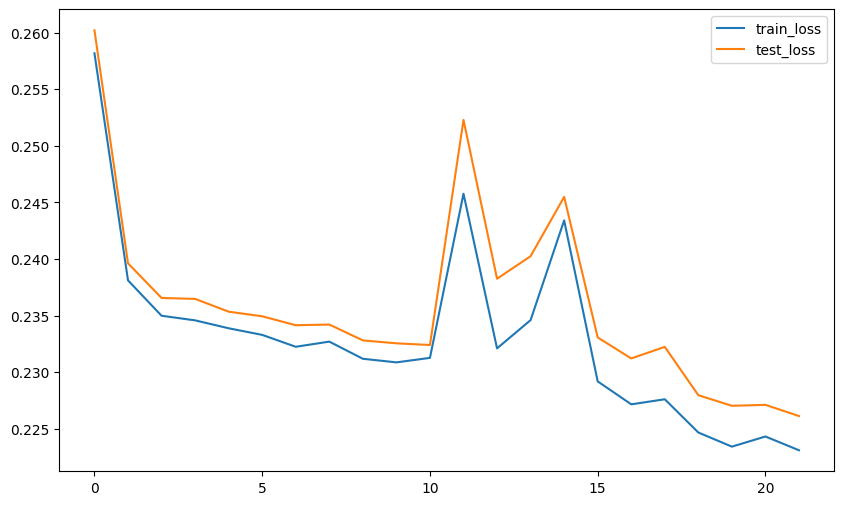

In [110]:
pd.DataFrame({'train_loss': train_losses, 'test_loss': test_losses}).plot(figsize=(10,6))

In [111]:
confusion_matrix(y_val, y_pred)

array([[10723,   106,   552,    36],
       [   23,  1346,   212,    11],
       [  116,   231,  5858,    39],
       [   29,    28,   138,   352]])

In [112]:
test_df = pd.read_csv('./kaggle/input/comment-category-prediction-challenge/test.csv')

In [113]:
test_df = test_df.drop(['created_date', 'post_id'], axis=1)

In [114]:
x_test_m = preprocessor.transform(test_df)

In [115]:
x_test_m = skb.transform(x_test_m)

### Consistency Check
y_main = pd.read_csv('submission_pc_mlp-4-32-11ep_skb6000.csv')['label']

y_main_pred = mlp.predict(x_test_m)

accuracy_score(y_main, y_main_pred)

In [57]:
pd.DataFrame({'ID':list(range(1,len(test_df)+1)),'label':mlp.predict(x_test_m)}).to_csv('submission_pc_mlp-4-32-11ep_skb6000.csv',index=False)

In [ ]:
pd.DataFrame({'ID':list(range(1,len(test_df)+1)),'label':clf_cw.predict(x_test_m)}).to_csv('submission_pc_rf_svd300.csv',index=False)